# Algorithmic Trading Project

This notebook downloads 1-hour OHLCV data from Binance for `BTCUSDT`, `ETHUSDT`, and an optional altcoin (`DOGEUSDT` by default), stores the raw market data in Parquet, audits data quality, constructs excess simple returns using the previous-step risk-free rate, flags return outliers with a rolling z-score filter, and displays the flagged rows without altering the original candles.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime, timezone
from IPython.display import display
import ccxt
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "SOL/USDT"]
TIMEFRAME  = "1h"
SINCE      = "2024-06-01"
DATA_DIR   = Path("data")

In [3]:
exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")


def write_parquet_safe(df: pd.DataFrame, path: Path) -> None:
    import pyarrow as pa
    import pyarrow.parquet as pq

    # Ensure destination folder exists before writing parquet.
    path.parent.mkdir(parents=True, exist_ok=True)

    # Bypass pandas' parquet wrapper, which can trip over Arrow extension
    # registration when notebook cells are re-run in the same kernel.
    table = pa.Table.from_pandas(df, preserve_index=True)
    pq.write_table(table, path)


for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since    = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME,
                                    since=since, limit=1000)
        if not bars:
            break
        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        now_ms = datetime.now(timezone.utc).timestamp() * 1000
        if bars[-1][0] >= now_ms - 3_600_000:
            break

    df = pd.DataFrame(all_bars,
                      columns=["timestamp", "open", "high", "low",
                                "close", "volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_1h.parquet"
    write_parquet_safe(df, fname)
    print(f" {len(df):,} bars → {fname}")

print("\nDone.")


Done.


### Macro Data — Effective Fed Funds Rate (FRED)

In [9]:
import os
from fredapi import Fred

# Set FRED_API_KEY in your environment before running this cell.
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 655 observations → data/DFF_daily.parquet


date
2026-03-13 00:00:00+00:00    3.64
2026-03-14 00:00:00+00:00    3.64
2026-03-15 00:00:00+00:00    3.64
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Cleaning

In [10]:
PROCESSED_DIR = DATA_DIR / "processed" / "binance"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

VALUE_COLUMNS = ["open", "high", "low", "close", "volume"]
RF_PATH = DATA_DIR / "DFF_daily.parquet"
HOURS_PER_YEAR = 24 * 365


def read_parquet_safe(path: Path) -> pd.DataFrame:
    import pyarrow.parquet as pq

    table = pq.read_table(path)
    return table.to_pandas()


def load_hourly_risk_free_rate(path: Path) -> pd.Series:
    rf_frame = read_parquet_safe(path)

    if isinstance(rf_frame, pd.Series):
        rf_series = rf_frame.rename("fed_funds_rate")
    elif "fed_funds_rate" in rf_frame.columns:
        rf_series = rf_frame["fed_funds_rate"]
    elif rf_frame.shape[1] == 1:
        rf_series = rf_frame.iloc[:, 0].rename("fed_funds_rate")
    else:
        raise ValueError(f"Could not identify the risk-free column in {path}")

    rf_index = pd.DatetimeIndex(rf_series.index)
    if rf_index.tz is None:
        rf_index = rf_index.tz_localize("UTC")
    else:
        rf_index = rf_index.tz_convert("UTC")

    rf_series.index = rf_index
    rf_series = rf_series.sort_index().astype(float)

    # DFF is quoted in annualized percent, so convert it to an hourly simple rate.
    return ((1.0 + rf_series.div(100.0)).pow(1.0 / HOURS_PER_YEAR) - 1.0).rename("risk_free_rate")


def audit_ohlcv(df: pd.DataFrame, symbol: str, stage: str) -> dict:
    audit_frame = df.sort_index().copy()
    index = pd.DatetimeIndex(audit_frame.index)

    if index.tz is None:
        index = index.tz_localize("UTC")
    else:
        index = index.tz_convert("UTC")

    audit_frame.index = index
    expected_index = pd.date_range(index.min(), index.max(), freq=TIMEFRAME, tz="UTC")
    gap_hours = index.to_series().diff().dropna().div(pd.Timedelta(hours=1))

    high_low_violations = (audit_frame["high"] < audit_frame["low"]).fillna(False)
    candle_rule_violations = (
        (audit_frame["high"] < audit_frame[["open", "close"]].max(axis=1))
        | (audit_frame["low"] > audit_frame[["open", "close"]].min(axis=1))
    ).fillna(False)

    return {
        "symbol": symbol,
        "stage": stage,
        "rows": len(audit_frame),
        "start": index.min(),
        "end": index.max(),
        "duplicate_timestamps": int(index.duplicated().sum()),
        "missing_bars": int(len(expected_index.difference(index))),
        "null_rows": int(audit_frame[VALUE_COLUMNS].isna().any(axis=1).sum()),
        "null_values": int(audit_frame[VALUE_COLUMNS].isna().sum().sum()),
        "non_positive_price_rows": int((audit_frame[["open", "high", "low", "close"]] <= 0).any(axis=1).sum()),
        "negative_volume_rows": int((audit_frame["volume"] < 0).sum()),
        "zero_volume_rows": int((audit_frame["volume"] == 0).sum()),
        "high_below_low_rows": int(high_low_violations.sum()),
        "candle_rule_violations": int(candle_rule_violations.sum()),
        "max_gap_hours": float(gap_hours.max()) if not gap_hours.empty else 0.0,
        "outliers_flagged": int(audit_frame["is_outlier"].sum()) if "is_outlier" in audit_frame else 0,
        "missing_bar_rows": int(audit_frame["missing_bar"].sum()) if "missing_bar" in audit_frame else 0,
    }


def flag_ohlcv_outliers(
    df: pd.DataFrame,
    risk_free_rate: pd.Series,
    rolling_window: int = 72,
    zscore_threshold: float = 5.0,
) -> pd.DataFrame:
    flagged = df.sort_index().copy()
    flagged.index = pd.DatetimeIndex(flagged.index)

    if flagged.index.tz is None:
        flagged.index = flagged.index.tz_localize("UTC")
    else:
        flagged.index = flagged.index.tz_convert("UTC")

    flagged.index.name = "timestamp"
    flagged["missing_bar"] = False
    flagged["simple_return"] = flagged["close"].pct_change()

    aligned_rf = risk_free_rate.reindex(flagged.index, method="ffill")
    flagged["risk_free_rate"] = aligned_rf.shift(1)
    flagged["excess_simple_return"] = flagged["simple_return"] - flagged["risk_free_rate"]

    min_periods = max(rolling_window // 3, 12)
    rolling_returns = flagged["excess_simple_return"].rolling(window=rolling_window, min_periods=min_periods)
    rolling_std = rolling_returns.std(ddof=0).replace(0.0, np.nan)
    flagged["return_zscore"] = (flagged["excess_simple_return"] - rolling_returns.mean()) / rolling_std
    flagged["is_outlier"] = flagged["return_zscore"].abs().gt(zscore_threshold).fillna(False)
    flagged["clean_return"] = flagged["excess_simple_return"]
    return flagged


risk_free_rate = load_hourly_risk_free_rate(RF_PATH)

flagged_frames = {}
quality_rows = []
flagged_rows = []

for symbol in SYMBOLS:
    raw_path = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    raw_df = read_parquet_safe(raw_path)
    raw_df.index = pd.DatetimeIndex(raw_df.index)

    quality_rows.append(audit_ohlcv(raw_df, symbol, "raw"))

    flagged_df = flag_ohlcv_outliers(raw_df, risk_free_rate=risk_free_rate)
    flagged_path = PROCESSED_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}_flagged.parquet"
    write_parquet_safe(flagged_df, flagged_path)

    flagged_frames[symbol] = flagged_df
    quality_rows.append(audit_ohlcv(flagged_df, symbol, "flagged"))

    symbol_flags = flagged_df.loc[
        flagged_df["is_outlier"],
        [
            "open",
            "high",
            "low",
            "close",
            "volume",
            "simple_return",
            "risk_free_rate",
            "excess_simple_return",
            "return_zscore",
        ],
    ].copy()
    symbol_flags.insert(0, "symbol", symbol)
    flagged_rows.append(symbol_flags.reset_index())

quality_report = pd.DataFrame(quality_rows).sort_values(["symbol", "stage"]).reset_index(drop=True)
display(quality_report)

post_clean_checks = quality_report.loc[
    quality_report["stage"] == "flagged",
    [
        "symbol",
        "missing_bars",
        "null_rows",
        "non_positive_price_rows",
        "negative_volume_rows",
        "high_below_low_rows",
        "candle_rule_violations",
        "outliers_flagged",
    ],
]
display(post_clean_checks)

flagged_outliers = pd.concat(flagged_rows, ignore_index=True).sort_values(["symbol", "timestamp"])
display(flagged_outliers)


,symbol,stage,rows,start,end,duplicate_timestamps,missing_bars,null_rows,null_values,non_positive_price_rows,negative_volume_rows,zero_volume_rows,high_below_low_rows,candle_rule_violations,max_gap_hours,outliers_flagged,missing_bar_rows
0,BTC/USDT,flagged,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,27,0
1,BTC/USDT,raw,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
2,DOGE/USDT,flagged,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,27,0
3,DOGE/USDT,raw,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
4,ETH/USDT,flagged,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,37,0
5,ETH/USDT,raw,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
6,SOL/USDT,flagged,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,23,0
7,SOL/USDT,raw,15761,2024-06-01 00:00:00+00:00,2026-03-19 16:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0


,symbol,missing_bars,null_rows,non_positive_price_rows,negative_volume_rows,high_below_low_rows,candle_rule_violations,outliers_flagged
0,BTC/USDT,0,0,0,0,0,0,27
2,DOGE/USDT,0,0,0,0,0,0,27
4,ETH/USDT,0,0,0,0,0,0,37
6,SOL/USDT,0,0,0,0,0,0,23


,timestamp,symbol,open,high,low,close,volume,simple_return,risk_free_rate,excess_simple_return,return_zscore
0,2024-06-12 12:00:00+00:00,BTC/USDT,67778.43,69488.00,67736.00,69339.29,5379.40042,0.023029,0.000006,0.023023,5.684964
1,2024-06-24 09:00:00+00:00,BTC/USDT,62730.92,62867.00,60567.01,61402.28,6567.42005,-0.021180,0.000006,-0.021186,-5.529886
2,2024-07-04 01:00:00+00:00,BTC/USDT,60430.01,60498.19,58444.00,58561.10,5938.30437,-0.030927,0.000006,-0.030933,-5.732817
3,2024-07-08 08:00:00+00:00,BTC/USDT,55852.00,57891.81,55741.11,57792.00,4740.11500,0.034734,0.000006,0.034729,5.115356
4,2024-08-12 14:00:00+00:00,BTC/USDT,58157.55,60711.09,57800.00,60299.98,5156.24546,0.036838,0.000006,0.036832,5.208797
...,...,...,...,...,...,...,...,...,...,...,...
109,2025-12-01 00:00:00+00:00,SOL/USDT,133.48,133.74,127.53,127.57,958104.52600,-0.044276,0.000004,-0.044281,-5.104471
110,2025-12-15 15:00:00+00:00,SOL/USDT,130.48,130.60,126.45,126.89,713478.62400,-0.027588,0.000004,-0.027592,-5.150818
111,2026-01-18 23:00:00+00:00,SOL/USDT,142.86,142.86,137.74,137.87,407539.60100,-0.034929,0.000004,-0.034933,-6.468612
112,2026-01-25 19:00:00+00:00,SOL/USDT,121.69,121.87,117.15,117.96,959971.67700,-0.030652,0.000004,-0.030656,-5.205040


### Excess Return Time Series

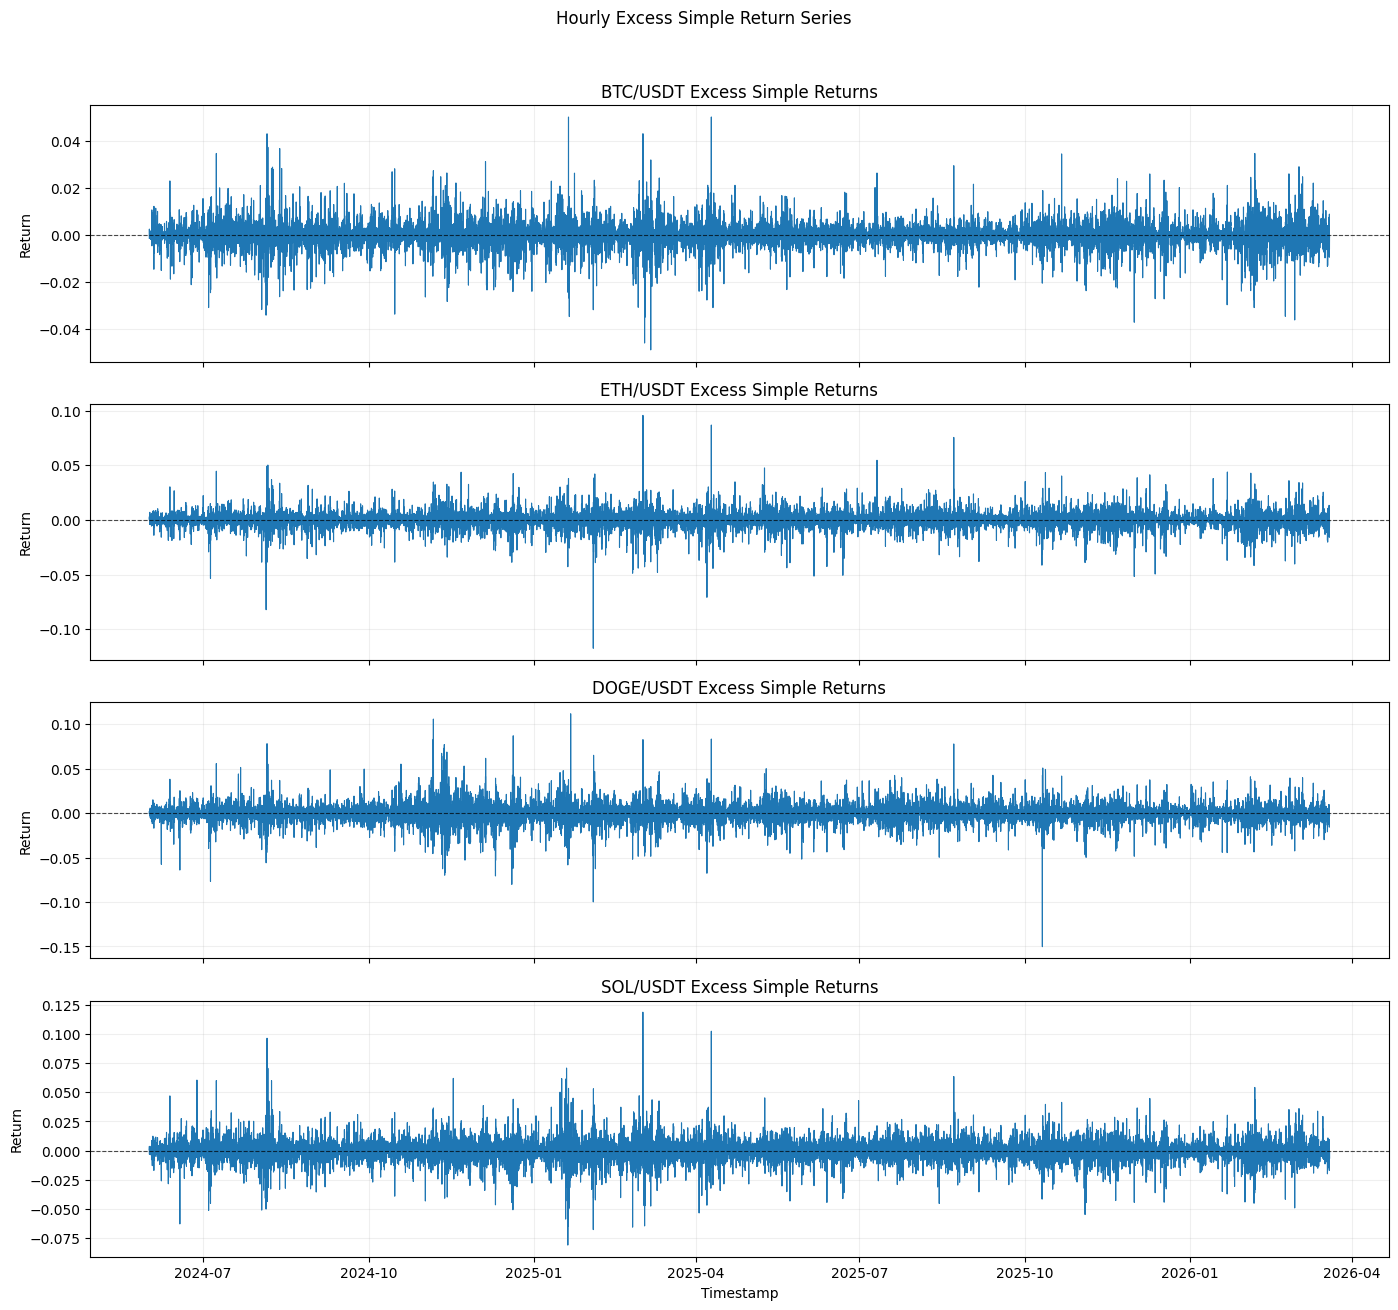

In [11]:
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(14, 3.2 * len(SYMBOLS)), sharex=True)

if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    plot_frame = flagged_frames[symbol]
    ax.plot(plot_frame.index, plot_frame["excess_simple_return"], lw=0.8, color="tab:blue")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.7)
    ax.set_title(f"{symbol} Excess Simple Returns")
    ax.set_ylabel("Return")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Hourly Excess Simple Return Series", y=1.02)
fig.tight_layout()
plt.show()
